<a href="https://colab.research.google.com/github/RenzoRav/-AulaVisualiza-odeDados/blob/main/Aula_Visualiza%C3%A7%C3%A3o_de_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Desafios de Visualização de Dados**

Recursos Úteis:

 * Data Viz Project: https://datavizproject.com/input/c/ - Um catálogo visual de gráficos para explorar.

* From Data to Viz: https://www.data-to-viz.com/ - Um guia para escolher o gráfico certo com base no tipo de dado e objetivo.

* Documentação Seaborn: https://seaborn.pydata.org/ - Para detalhes sobre os parâmetros de estilo e plotagem.

* Documentação Matplotlib: https://matplotlib.org/stable/contents.html - Para controle fino sobre elementos do gráfico.



## **0: Configuração Inicial**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações padrão para gráficos (para começar limpo)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

print("Bibliotecas importadas e configurações aplicadas!")

Bibliotecas importadas e configurações aplicadas!


### 1: Desafios de Decisão

Para cada cenário abaixo, você receberá um conjunto de dados e uma pergunta de negócio. Sua tarefa é:

1. Analisar a pergunta e o tipo de dado.

2. Consultar o Data Viz Project ou From Data to Viz para identificar o tipo de gráfico mais adequado.

3. Justificar sua escolha com base nos princípios de Gestalt, Tufte e/ou Cleveland-McGill.

4. Implementar o gráfico usando matplotlib e seaborn. Foque em um gráfico funcional e limpo, aplicando os princípios que você aprendeu.

Desafio 1.1: Comparação de Vendas por Região

Cenário: Uma empresa de varejo quer comparar o desempenho de vendas de suas quatro regiões no último trimestre para identificar qual delas precisa de mais atenção.



In [ ]:
# Dados para o Desafio 1.1
dados_regiao = {
    'Regiao': ['Norte', 'Sul', 'Leste', 'Oeste'],
    'Vendas_Milhoes': [12.5, 18.2, 15.0, 9.8]
}
df_regiao = pd.DataFrame(dados_regiao)
print("\nDataFrame para Desafio 1.1:")
print(df_regiao)


DataFrame para Desafio 1.1:
  Regiao  Vendas_Milhoes
0  Norte            12.5
1    Sul            18.2
2  Leste            15.0
3  Oeste             9.8


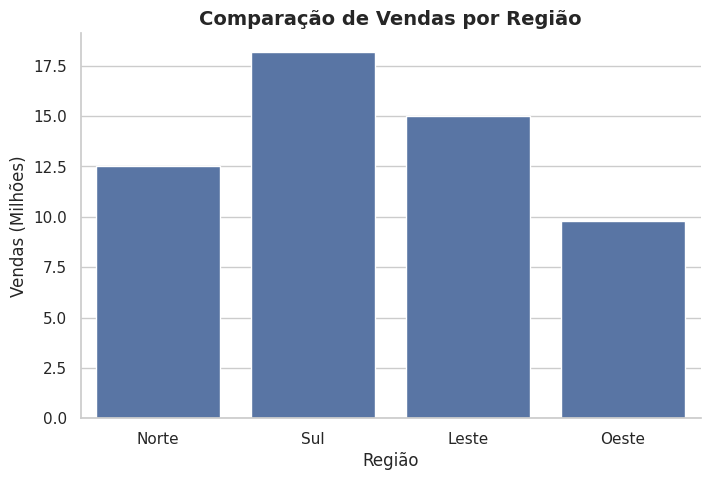

In [ ]:
# 1. Gráfico de barras

# 2. Justificativa:
# O gráfico de barras é o mais adequado porque o objetivo é comparar
# valores de vendas entre categorias. Seguindo Tufte, o gráfico de barras permite
# uma visualização limpa e objetiva, sem elementos desnecessários.

plt.figure(figsize=(8, 5))
sns.barplot(data=df_regiao, x='Regiao', y='Vendas_Milhoes')

plt.title('Comparação de Vendas por Região', fontsize=14, fontweight='bold')
plt.xlabel('Região')
plt.ylabel('Vendas (Milhões)')

sns.despine()
plt.show()

Desafio 1.2: Distribuição de Idades de Clientes

Cenário: Uma equipe de marketing quer entender a distribuição de idade de seus clientes para segmentar campanhas. Eles têm dados de idade de 1000 clientes.

In [ ]:
# Dados para o Desafio 1.2
np.random.seed(42)
idades = np.random.normal(loc=35, scale=10, size=1000).astype(int)
idades = idades[(idades >= 18) & (idades <= 70)] # Limitar idades razoáveis
df_idades = pd.DataFrame({'Idade': idades})
print("\nDataFrame para Desafio 1.2 (primeiras 5 linhas):")
print(df_idades.head())


DataFrame para Desafio 1.2 (primeiras 5 linhas):
   Idade
0     39
1     33
2     41
3     50
4     32


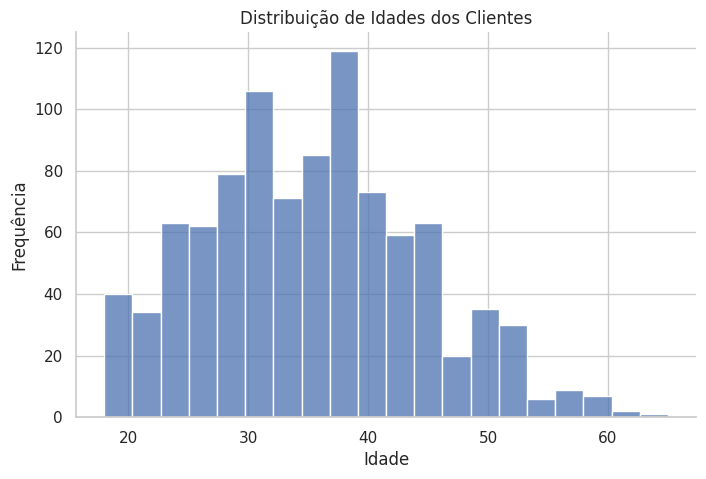

In [ ]:
# 1. Histograma

# 2. Justificativa:
# O histograma é adequado porque o objetivo é analisar a distribuição
# das idades dos clientes. Esse tipo de gráfico permite visualizar a
# frequência de valores dentro de intervalos. Segundo Cleveland-McGill,
# a percepção por posição ao longo de um eixo comum facilita a leitura.

plt.figure(figsize=(8,5))

sns.histplot(df_idades['Idade'], bins=20)

plt.title('Distribuição de Idades dos Clientes')
plt.xlabel('Idade')
plt.ylabel('Frequência')

sns.despine()
plt.show()

Desafio 1.3: Tendência de Acessos ao Site

Cenário: A equipe de produto quer monitorar a evolução diária do número de acessos ao site nos últimos 30 dias para identificar padrões ou quedas.

In [ ]:
# Dados para o Desafio 1.3
datas = pd.date_range(start='2024-03-01', periods=30)
np.random.seed(42)
acessos = np.random.randint(1000, 5000, 30)
# Simular uma queda nos últimos dias
acessos[-5:] = np.random.randint(500, 1500, 5)
df_acessos = pd.DataFrame({'Data': datas, 'Acessos': acessos})
print("\nDataFrame para Desafio 1.3 (primeiras 5 linhas):")
print(df_acessos.head())


DataFrame para Desafio 1.3 (primeiras 5 linhas):
        Data  Acessos
0 2024-03-01     4174
1 2024-03-02     4507
2 2024-03-03     1860
3 2024-03-04     2294
4 2024-03-05     2130


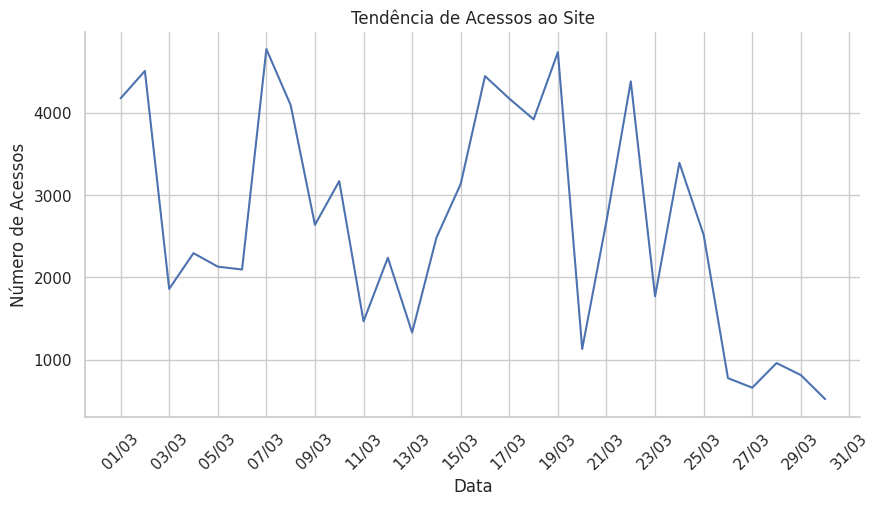

In [ ]:
# 1. Gráfico de linha

# 2. Justificativa:
# O gráfico de linha é o mais adequado porque o objetivo é analisar a
# evolução dos acessos ao longo do tempo. Esse tipo de gráfico permite
# identificar tendências, padrões e variações. Segundo Cleveland-McGill,
# a percepção de posição ao longo de um eixo comum facilita a leitura
# de mudanças.

import matplotlib.dates as mdates

plt.figure(figsize=(10,5))

sns.lineplot(data=df_acessos, x='Data', y='Acessos')

plt.title('Tendência de Acessos ao Site')
plt.xlabel('Data')
plt.ylabel('Número de Acessos')

# FORMATAÇÃO DAS DATAS
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

plt.xticks(rotation=45)

sns.despine()
plt.show()

Desafio 1.4: Relação entre Investimento em Marketing e Vendas

Cenário: A equipe de finanças quer entender se há uma correlação entre o investimento mensal em marketing e o volume de vendas gerado no mesmo mês.

In [ ]:
# Dados para o Desafio 1.4
np.random.seed(42)
investimento_marketing = np.random.randint(10000, 50000, 12)
vendas_mensais = investimento_marketing * 5 + np.random.randint(-5000, 5000, 12)
df_marketing_vendas = pd.DataFrame({
    'Investimento_Marketing': investimento_marketing,
    'Vendas_Mensais': vendas_mensais
})
print("\nDataFrame para Desafio 1.4 (primeiras 5 linhas):")
print(df_marketing_vendas.head())


DataFrame para Desafio 1.4 (primeiras 5 linhas):
   Investimento_Marketing  Vendas_Mensais
0                   25795          129286
1                   10860           54351
2                   48158          242210
3                   21284          102604
4                   16265           80880


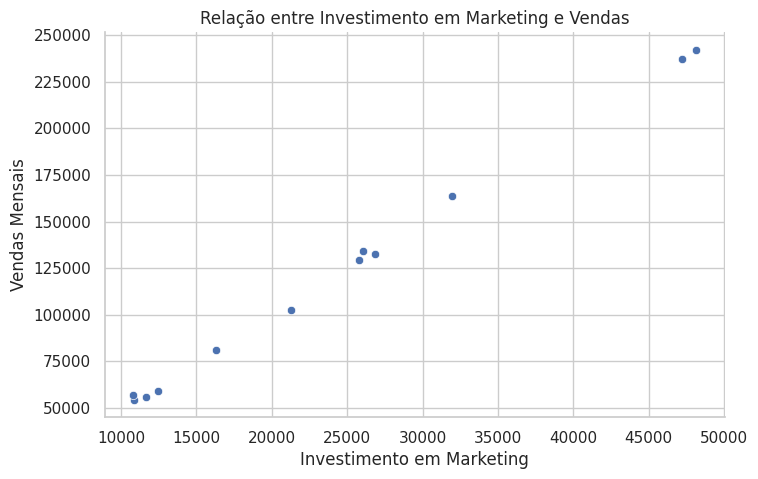

In [ ]:
# 1. Gráfico de dispersão

# 2. Justificativa:
# O gráfico de dispersão é o mais adequado porque o objetivo é analisar
# a relação entre duas variáveis numéricas: investimento em marketing e
# vendas mensais. Esse tipo de gráfico permite identificar correlação,
# tendências e possíveis padrões. Segundo Cleveland-McGill, a posição
# dos pontos em dois eixos comuns facilita a comparação.
# O gráfico é simples e direto, seguindo a ideia de Tufte de evitar
# elementos desnecessários.


plt.figure(figsize=(8,5))

sns.scatterplot(data=df_marketing_vendas,
                x='Investimento_Marketing',
                y='Vendas_Mensais')

plt.title('Relação entre Investimento em Marketing e Vendas')
plt.xlabel('Investimento em Marketing')
plt.ylabel('Vendas Mensais')

sns.despine()
plt.show()

Desafio 1.5: Composição de Mercado por Categoria de Produto

Cenário: Um analista de mercado quer visualizar a proporção de cada categoria de produto no total de vendas da empresa para entender a dominância de certas categorias.

In [ ]:
# Dados para o Desafio 1.5
dados_categorias = {
    'Categoria': ['Eletrônicos', 'Vestuário', 'Alimentos', 'Livros', 'Serviços'],
    'Vendas_Milhoes': [35.0, 20.0, 15.0, 10.0, 5.0]
}
df_categorias = pd.DataFrame(dados_categorias)
print("\nDataFrame para Desafio 1.5:")
print(df_categorias)


DataFrame para Desafio 1.5:
     Categoria  Vendas_Milhoes
0  Eletrônicos            35.0
1    Vestuário            20.0
2    Alimentos            15.0
3       Livros            10.0
4     Serviços             5.0


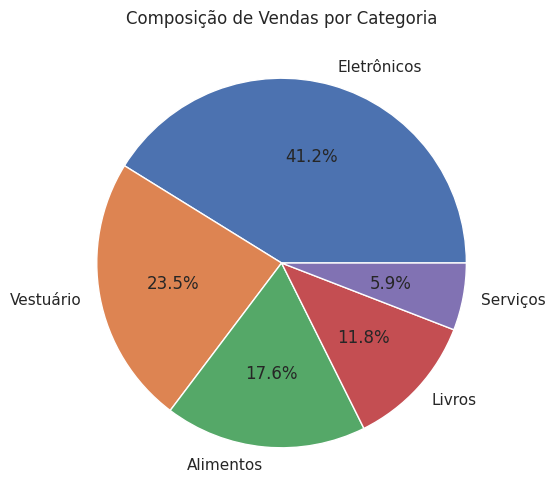

In [ ]:
# 1. Gráfico de pizza

# 2. Justificativa:
# O gráfico de pizza é adequado porque o objetivo é visualizar a proporção
# de cada categoria no total de vendas. Esse tipo de gráfico permite
# identificar facilmente a participação relativa de cada parte. Segundo
# os princípios de Gestalt, as partes de um todo são percebidas como um
# conjunto, facilitando a compreensão da composição.

plt.figure(figsize=(6,6))

plt.pie(df_categorias['Vendas_Milhoes'],
        labels=df_categorias['Categoria'],
        autopct='%1.1f%%')

plt.title('Composição de Vendas por Categoria')

plt.show()

### Parte 2: Desafios de Refatoração Crítica

Para cada cenário abaixo, você receberá um código Python que gera um gráfico com problemas de design. Sua tarefa é:

1. Analisar o gráfico gerado e identificar pelo menos 3 problemas com base nos princípios de Tufte (Data-Ink Ratio, Lie Factor, Chartjunk), Gestalt (Proximidade, Semelhança, Fechamento, etc.) e/ou Cleveland-McGill (eficácia da codificação).

2. Descrever os problemas identificados.

3. Modificar o código para refatorar o gráfico, aplicando os princípios para torná-lo mais honesto, eficiente e visualmente claro.



Desafio 2.1: Vendas Trimestrais com Eixo Y Enganoso

Cenário: Um gerente de vendas recebeu este gráfico e está preocupado com uma suposta queda drástica nas vendas do Q4.

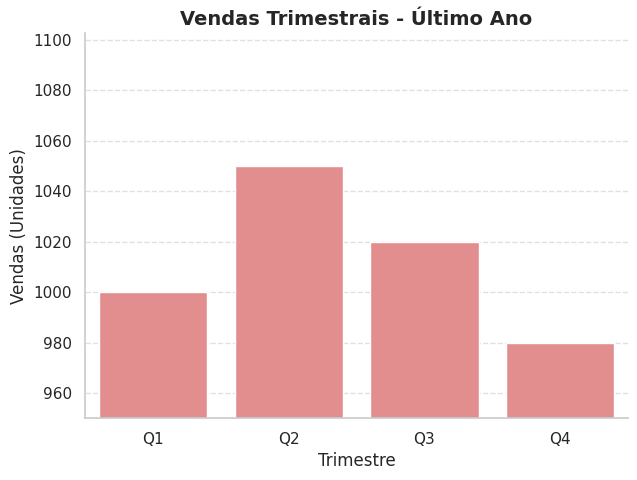

In [ ]:
# Dados para o Desafio 2.1
dados_trimestrais = {
    'Trimestre': ['Q1', 'Q2', 'Q3', 'Q4'],
    'Vendas': [1000, 1050, 1020, 980]
}
df_trimestral = pd.DataFrame(dados_trimestrais)

plt.figure(figsize=(7, 5))
ax = sns.barplot(x='Trimestre', y='Vendas', data=df_trimestral, color='lightcoral')
ax.set_ylim(bottom=950) # Eixo Y começando alto
ax.set_title('Vendas Trimestrais - Último Ano', fontsize=14, fontweight='bold')
ax.set_xlabel('Trimestre')
ax.set_ylabel('Vendas (Unidades)')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

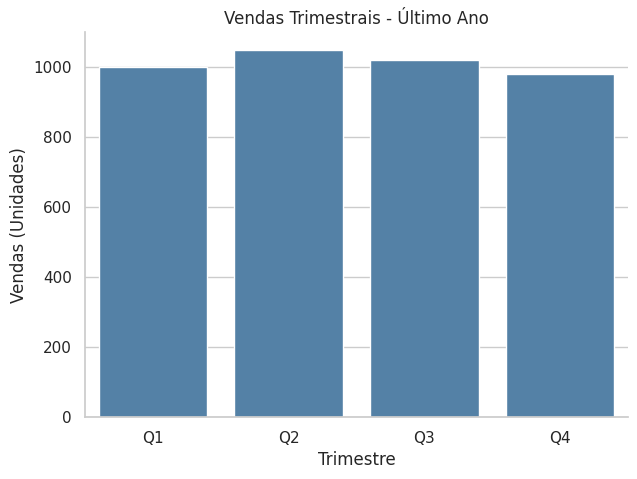

In [ ]:
# 1. Problemas identificados:

# a) O eixo Y não começa em zero, o que exagera visualmente a diferença entre os valores.

# b) O gráfico induz a interpretação de uma queda muito grande no Q4, quando a variação real é pequena.

# c) Uso de cor e escala que reforçam uma percepção enganosa (data-ink mal utilizado).

# d) Falta de contexto ou referência que ajude a interpretar se a variação é significativa.


plt.figure(figsize=(7,5))

sns.barplot(data=df_trimestral, x='Trimestre', y='Vendas', color='steelblue')

plt.title('Vendas Trimestrais - Último Ano')
plt.xlabel('Trimestre')
plt.ylabel('Vendas (Unidades)')

plt.ylim(0, 1100)  # começa do zero

sns.despine()
plt.show()


# a) Eixo Y agora começa em zero → visual honesto

# b) Removido exagero visual da queda

# c) Cor mais neutra → evita manipulação emocional

# d) Gráfico mais limpo e fácil de interpretar


Desafio 2.2: Comparação de Produtos com Gráfico de Pizza Lotado

Cenário: A equipe de produto quer ver a proporção de vendas de 8 produtos diferentes, mas o gráfico atual está confuso.

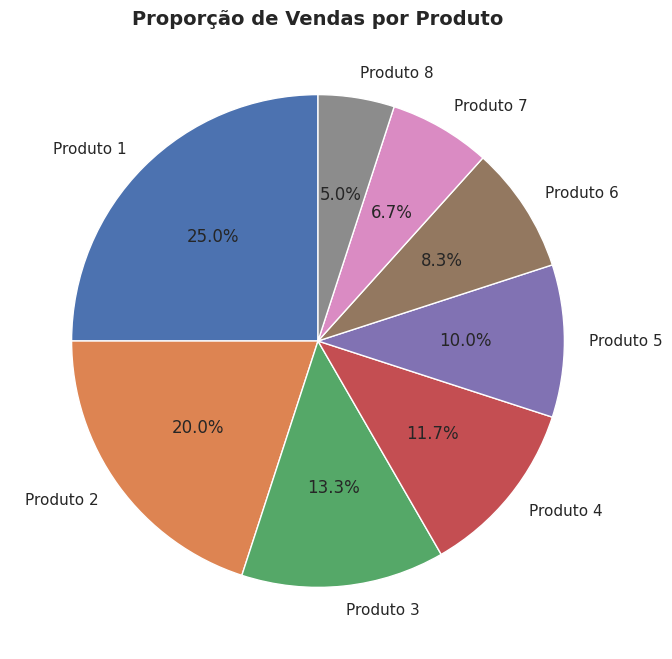

In [ ]:
# Dados para o Desafio 2.2
dados_produtos = {
    'Produto': [f'Produto {i}' for i in range(1, 9)],
    'Vendas': [150, 120, 80, 70, 60, 50, 40, 30]
}
df_produtos = pd.DataFrame(dados_produtos)

plt.figure(figsize=(8, 8))
plt.pie(df_produtos['Vendas'], labels=df_produtos['Produto'], autopct='%1.1f%%', startangle=90)
plt.title('Proporção de Vendas por Produto', fontsize=14, fontweight='bold')
plt.show()

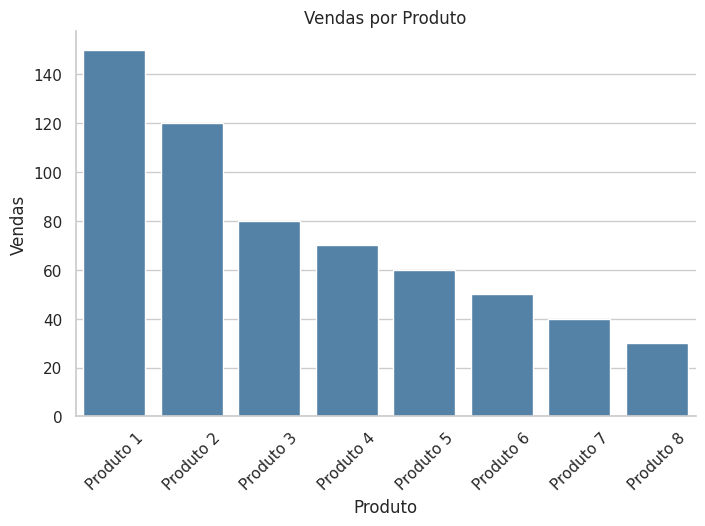

In [ ]:
# 1. Problemas identificados:

# a) Muitas categorias (8 produtos), o que dificulta a leitura no gráfico de pizza.

# b) Diferenças pequenas entre fatias são difíceis de comparar (ângulo é ruim para percepção).

# c) Excesso de rótulos e porcentagens torna o gráfico visualmente poluído.

# d) O gráfico não permite comparação precisa entre os valores (Cleveland-McGill).

plt.figure(figsize=(8,5))

sns.barplot(data=df_produtos,
            x='Produto',
            y='Vendas',
            color='steelblue')

plt.title('Vendas por Produto')
plt.xlabel('Produto')
plt.ylabel('Vendas')

plt.xticks(rotation=45)

sns.despine()
plt.show()

# a) Melhor comparação entre valores (comprimento > ângulo)

# b) Redução da poluição visual

# c) Leitura mais clara e rápida

# d) Melhor aderência aos princípios de Cleveland-McGill

Desafio 2.3: Desempenho de Funcionários com Cores Aleatórias

Cenário: O RH quer visualizar o desempenho (pontuação de 0 a 100) de 5 funcionários em uma avaliação, mas o gráfico atual usa cores sem sentido.

/tmp/ipykernel_20675/178950125.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Funcionario', y='Pontuacao', data=df_funcionarios, palette=cores_aleatorias)


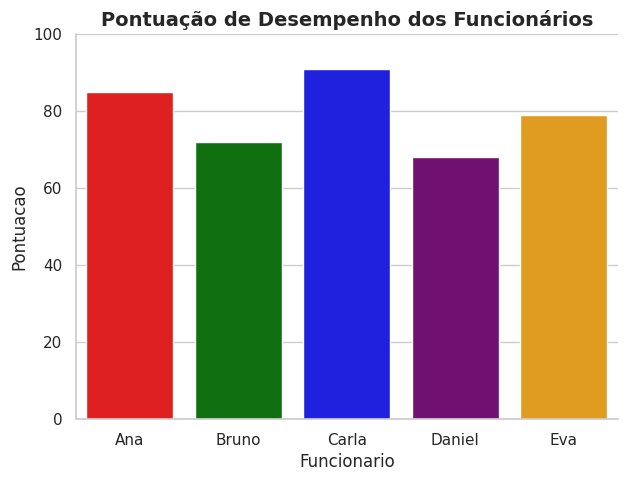

In [ ]:
# Dados para o Desafio 2.3
dados_funcionarios = {
    'Funcionario': ['Ana', 'Bruno', 'Carla', 'Daniel', 'Eva'],
    'Pontuacao': [85, 72, 91, 68, 79]
}
df_funcionarios = pd.DataFrame(dados_funcionarios)

plt.figure(figsize=(7, 5))
cores_aleatorias = ['red', 'green', 'blue', 'purple', 'orange']
ax = sns.barplot(x='Funcionario', y='Pontuacao', data=df_funcionarios, palette=cores_aleatorias)
ax.set_title('Pontuação de Desempenho dos Funcionários', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
plt.show()

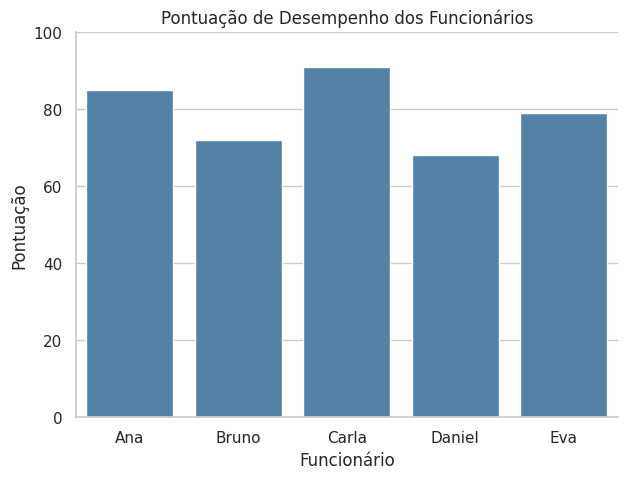

In [ ]:
# 1. Problemas identificados:

# a) As cores são aleatórias e não representam nenhuma informação relevante.

# b) O uso de muitas cores diferentes cria ruído visual e dificulta a leitura.

# c) O gráfico sugere que cada cor tem um significado, mas isso não acontece.

# d) Há excesso de destaque visual sem necessidade, o que vai contra a clareza na visualização.

plt.figure(figsize=(7,5))

sns.barplot(data=df_funcionarios, x='Funcionario', y='Pontuacao', color='steelblue')

plt.title('Pontuação de Desempenho dos Funcionários')
plt.xlabel('Funcionário')
plt.ylabel('Pontuação')
plt.ylim(0, 100)

sns.despine()
plt.show()

# a) Removidas cores aleatórias sem significado

# b) Reduzido ruído visual

# c) Mantido foco na comparação das pontuações

# d) Gráfico mais claro, honesto e eficiente


Desafio 2.4: Gráfico de Linhas com Chartjunk Excessivo

Cenário: Um analista de dados criou este gráfico para mostrar a evolução de duas métricas ao longo do tempo, mas ele está muito poluído.

/tmp/ipykernel_20675/3038338850.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datas_mes = pd.date_range(start='2023-01-01', periods=12, freq='M')


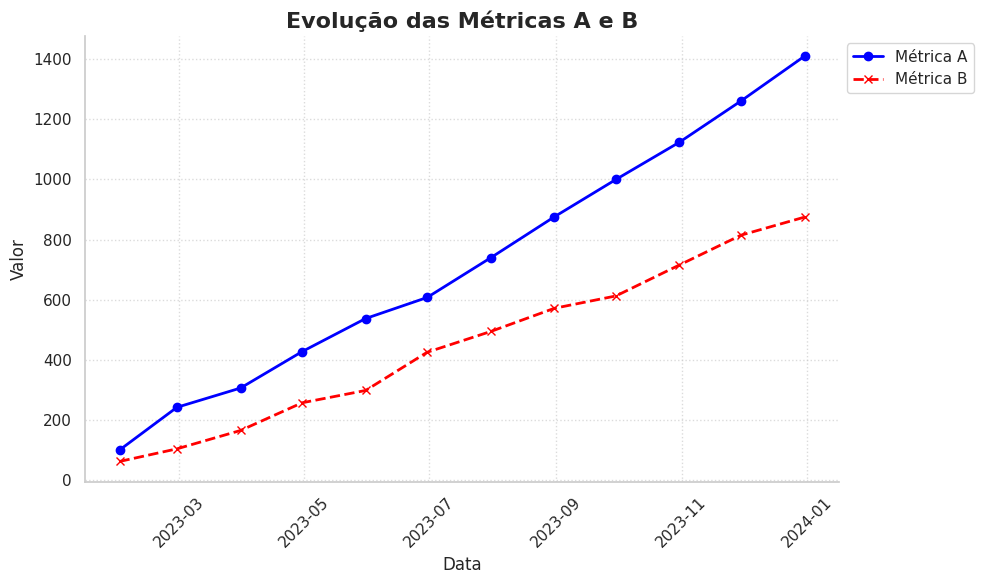

In [ ]:
# Dados para o Desafio 2.4
datas_mes = pd.date_range(start='2023-01-01', periods=12, freq='M')
np.random.seed(42)
metrica_a = np.random.randint(50, 150, 12).cumsum()
metrica_b = np.random.randint(40, 130, 12).cumsum()

df_metricas = pd.DataFrame({
    'Data': datas_mes,
    'Metrica_A': metrica_a,
    'Metrica_B': metrica_b
})

plt.figure(figsize=(10, 6))
plt.plot(df_metricas['Data'], df_metricas['Metrica_A'], label='Métrica A', marker='o', linestyle='-', linewidth=2, color='blue')
plt.plot(df_metricas['Data'], df_metricas['Metrica_B'], label='Métrica B', marker='x', linestyle='--', linewidth=2, color='red')

plt.title('Evolução das Métricas A e B', fontsize=16, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Valor', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

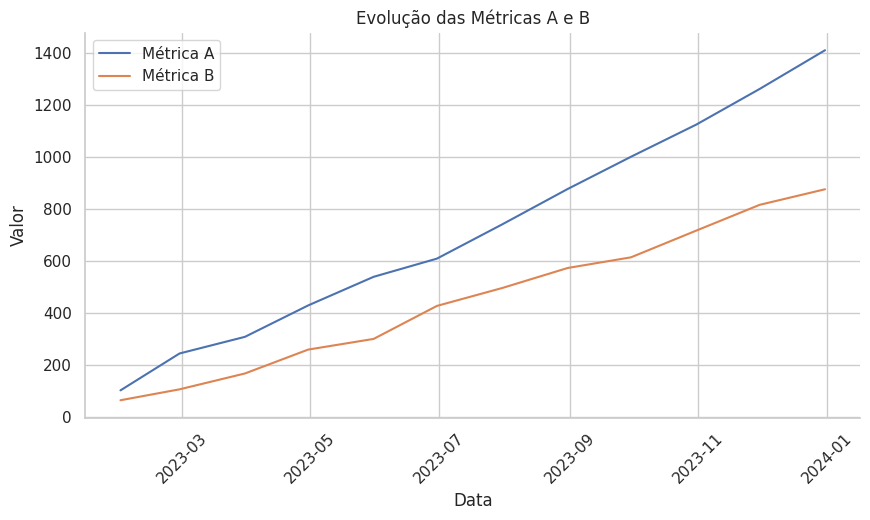

In [ ]:
# 1. Problemas identificados:

# a) Uso excessivo de elementos visuais (marcadores, linhas tracejadas, cores fortes).

# b) Excesso de informação visual que não agrega valor (chartjunk).

# c) Grade muito destacada, competindo com os dados.

# d) Estilos diferentes nas linhas (tracejada vs contínua) sem necessidade.

# e) Poluição visual que dificulta a leitura da tendência.

plt.figure(figsize=(10,5))

sns.lineplot(data=df_metricas, x='Data', y='Metrica_A', label='Métrica A')
sns.lineplot(data=df_metricas, x='Data', y='Metrica_B', label='Métrica B')

plt.title('Evolução das Métricas A e B')
plt.xlabel('Data')
plt.ylabel('Valor')

plt.xticks(rotation=45)

sns.despine()
plt.show()

# a) Remoção de marcadores desnecessários

# b) Remoção de linhas tracejadas

# c) Redução da poluição visual

# d) Foco nas tendências

# e) Gráfico mais limpo e profissional (Tufte)

Desafio 2.5: Comparação de Desempenho com Gráfico de Bolhas Confuso

Cenário: Um gerente de produto quer comparar o desempenho de diferentes funcionalidades (Funcionalidade 1 a 5) com base em duas métricas: 'Uso' e 'Satisfação'. O tamanho da bolha representa o 'Impacto'.

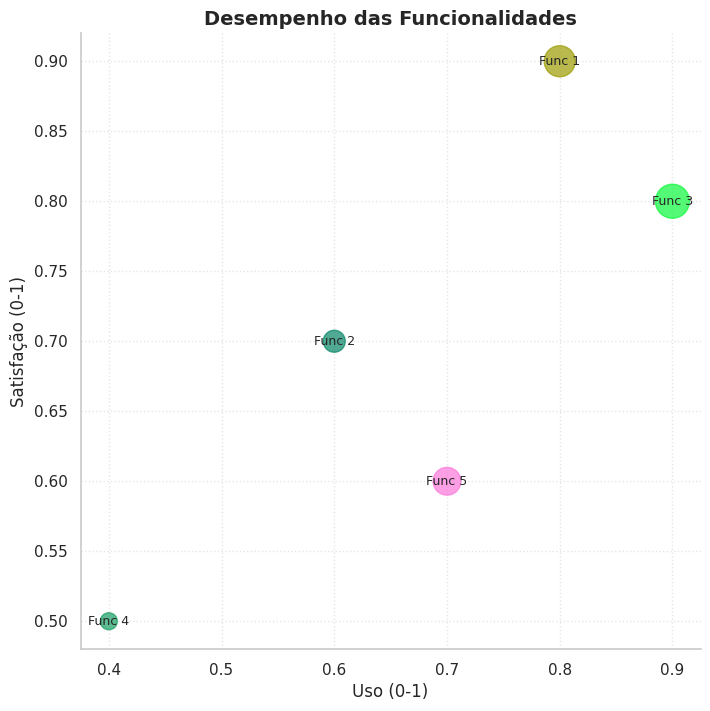

In [ ]:
# Dados para o Desafio 2.5
dados_funcionalidades = {
    'Funcionalidade': [f'Func {i}' for i in range(1, 6)],
    'Uso': [0.8, 0.6, 0.9, 0.4, 0.7],
    'Satisfacao': [0.9, 0.7, 0.8, 0.5, 0.6],
    'Impacto': [100, 50, 120, 30, 80]
}
df_funcionalidades = pd.DataFrame(dados_funcionalidades)

plt.figure(figsize=(8, 8))
plt.scatter(x=df_funcionalidades['Uso'], y=df_funcionalidades['Satisfacao'],
            s=df_funcionalidades['Impacto']*5, # Multiplicar para bolhas maiores
            alpha=0.7,
            c=np.random.rand(len(df_funcionalidades), 3)) # Cores aleatórias

for i, row in df_funcionalidades.iterrows():
    plt.text(row['Uso'], row['Satisfacao'], row['Funcionalidade'], fontsize=9, ha='center', va='center')

plt.title('Desempenho das Funcionalidades', fontsize=14, fontweight='bold')
plt.xlabel('Uso (0-1)', fontsize=12)
plt.ylabel('Satisfação (0-1)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

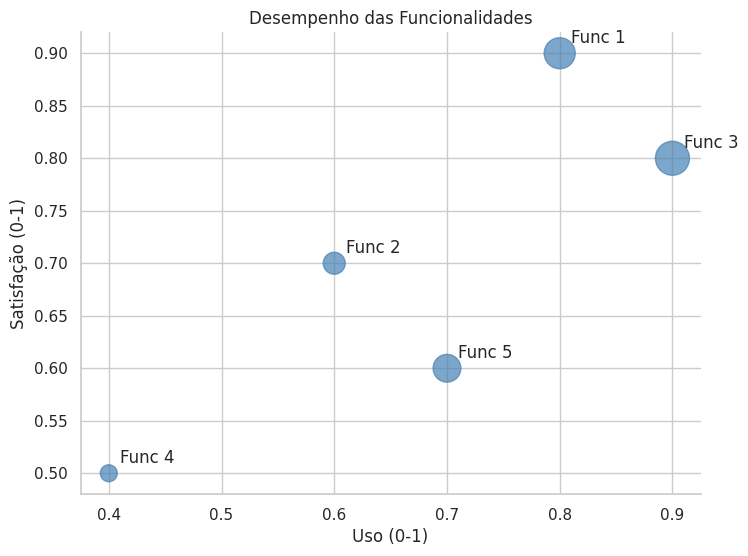

In [ ]:
# 1. Problemas identificados:

# a) Uso de cores aleatórias sem significado, gerando confusão visual.

# b) Tamanho das bolhas (impacto) não está claramente interpretável.

# c) Falta de legenda para explicar o tamanho das bolhas.

# d) Rótulos sobrepostos às bolhas, dificultando a leitura.

# e) Poluição visual geral que prejudica a análise.


plt.figure(figsize=(8,6))

plt.scatter(
    df_funcionalidades['Uso'],
    df_funcionalidades['Satisfacao'],
    s=df_funcionalidades['Impacto'] * 5,
    color='steelblue',
    alpha=0.7
)

# adicionar rótulos com leve deslocamento
for i, row in df_funcionalidades.iterrows():
    plt.text(row['Uso'] + 0.01, row['Satisfacao'] + 0.01, row['Funcionalidade'])

plt.title('Desempenho das Funcionalidades')
plt.xlabel('Uso (0-1)')
plt.ylabel('Satisfação (0-1)')

sns.despine()
plt.show()

# a) Remoção de cores aleatórias → agora uma cor só

# b) Transparência (alpha) para melhorar visual

# c) Rótulos reposicionados → melhor leitura

# d) Redução da poluição visual

# e) Melhor foco na relação entre uso e satisfação
